# Step 2.1 — Feature Engineering: TF-IDF

**Goal:** Convert the cleaned, lemmatized legal texts (`text_clean`) into numerical vectors using **TF-IDF** (Term Frequency–Inverse Document Frequency).

**Why TF-IDF?**  
TF-IDF assigns each token a weight that reflects how important it is *within a document* relative to *across the corpus*. A word that appears often in one law but rarely across all laws gets a high weight — exactly the signal we want for clustering. Key advantages for our use case:
- **Interpretable:** Each dimension corresponds to a known token, making cluster analysis transparent.
- **Sparse:** Most tokens appear in few documents; sparse matrices are memory-efficient.
- **No training required:** Unlike embeddings, TF-IDF is computed directly from the corpus.
- **Proven baseline:** TF-IDF is a standard starting point for document clustering; deviations from it are easy to motivate in the report.

**Limitation:** TF-IDF treats each word independently (bag-of-words). It cannot capture semantic similarity between different words (e.g., *Schule* and *Bildung*). Step 2.2 addresses this with Word2Vec embeddings.

## 1. Setup

In [16]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import os

CLEAN_DATA_PATH  = "../data/processed/sgbs_clean.csv"
TFIDF_MATRIX_PATH = "../data/processed/tfidf_matrix.npz"
TFIDF_VOCAB_PATH  = "../data/processed/tfidf_vocab.csv"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../report/figures", exist_ok=True)

df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Records loaded: {len(df)}")
df.head(2)

Records loaded: 733


,title_de,keywords_de,text_of_law,systematic_number,category_name,category_id,text_lemmatized,text_clean
0,Entfernung der Spitalliste aus der Gesetzessam...,NaN,Spitäler\n\n\n 330.500\n\n\n Entfernung der ...,330.500,Anderes,5.0,spitäler entfernung spitalliste gesetzessammlu...,spitäler entfernung spitalliste spitalliste sp...
1,Staatsvertrag zwischen den Kantonen Basel-Stad...,NaN,Gesundheitsversorgung: Staatsvertrag BL + BS |...,333.200,Interkantonale Vereinbarung,2.0,gesundheitsversorgung staatsvertrag koordinati...,gesundheitsversorgung staatsvertrag spitalwese...


## 2. Fit TF-IDF

Key hyperparameters:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `min_df` | 3 | Ignore tokens appearing in fewer than 3 documents — hapax legomena add noise |
| `max_df` | 0.85 | Ignore tokens in more than 85% of documents — residual near-universal terms |
| `max_features` | 5000 | Cap vocabulary size to keep matrix manageable for clustering |
| `sublinear_tf` | True | Apply log(1+tf) instead of raw tf — compresses outliers from very long laws |
| `ngram_range` | (1,1) | Unigrams only; bigrams increase dimensionality without clear benefit here |
| `token_pattern` | alphabetic only | Restricts to pure letter tokens (incl. umlauts); excludes article-number tokens like `12a`, `16b` that spaCy's `like_num` does not catch |

In [17]:
vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.85,
    max_features=5000,
    sublinear_tf=True,
    ngram_range=(1, 1),
    # Only pure alphabetic tokens (incl. German umlauts).
    # Excludes article-number tokens like '12a', '16b' that slipped through
    # spaCy's like_num filter during lemmatization.
    token_pattern=r'(?u)\b[a-z\u00e4\u00f6\u00fc\u00df][a-z\u00e4\u00f6\u00fc\u00df-]{2,}\b'
)

texts = df["text_clean"].fillna("").tolist()
X_tfidf = vectorizer.fit_transform(texts)

print(f"Matrix shape:    {X_tfidf.shape}  (documents × features)")
print(f"Non-zero entries: {X_tfidf.nnz:,}")
print(f"Sparsity:        {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.1%}")

Matrix shape:    (733, 5000)  (documents × features)
Non-zero entries: 93,078
Sparsity:        97.5%


## 3. Inspect Vocabulary

In [18]:
vocab = vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample tokens: {list(vocab[:20])}")

Vocabulary size: 5000
Sample tokens: ['a-zug', 'aargau', 'abbau', 'abberufen', 'abberufung', 'abbruch', 'abdankung', 'abdankungsfeier', 'abdecken', 'abends', 'abfall', 'abfallanlag', 'abfallbeseitigung', 'abfindung', 'abführen', 'abgabekommission', 'abgabepflicht', 'abgabepflichtig', 'abgeben', 'abgegeben']


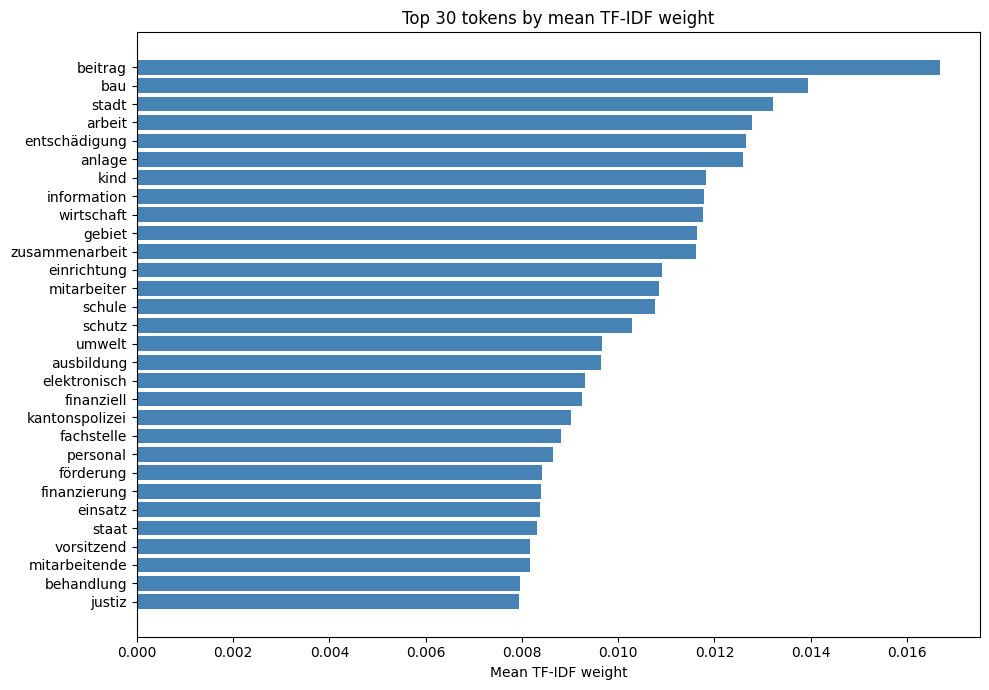

Figure saved.


,token,mean_tfidf
0,beitrag,0.016685
1,bau,0.013942
2,stadt,0.013211
3,arbeit,0.012776
4,entschädigung,0.012663
5,anlage,0.012584
6,kind,0.011821
7,information,0.011793
8,wirtschaft,0.011763
9,gebiet,0.011641


In [19]:
# Top tokens by mean TF-IDF weight across all documents
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:30]

top_df = pd.DataFrame({
    "token": vocab[top_idx],
    "mean_tfidf": mean_tfidf[top_idx]
})

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_df["token"][::-1], top_df["mean_tfidf"][::-1], color="steelblue")
ax.set_xlabel("Mean TF-IDF weight")
ax.set_title("Top 30 tokens by mean TF-IDF weight")
plt.tight_layout()
plt.savefig("../report/figures/02_1_tfidf_top_tokens.png", dpi=150)
plt.show()
print("Figure saved.")

top_df

## 4. Sanity Check — Per-Document Coverage

In [25]:
# How many features are non-zero per document?
nonzero_per_doc = np.diff(X_tfidf.indptr)
print(f"Avg non-zero features per document: {nonzero_per_doc.mean():.0f}")
print(f"Min: {nonzero_per_doc.min()}   Max: {nonzero_per_doc.max()}")

# Flag any documents with very few features (might be too short to cluster reliably)
thin_docs = df[nonzero_per_doc < 10][["title_de", "systematic_number"]]
print(f"\nDocuments with <10 non-zero features: {len(thin_docs)}")
if len(thin_docs):
    print(thin_docs.to_string())

Avg non-zero features per document: 127
Min: 3   Max: 1276

Documents with <10 non-zero features: 15
                                                                                                                                                   title_de systematic_number
0                                                                                                       Entfernung der Spitalliste aus der Gesetzessammlung           330.500
38                                                                                                                                       Denkmalverzeichnis           497.300
90                                                                                                                 Verordnung über die Strassenprostitution           724.500
140                   Beschluss des Regierungsrates betreffend Zuständigkeit zur Verzeigung von an Bord schweizerischer Seeschiffe begangenen Übertretungen           955.900
147                          

## 5. Persist

In [26]:
# Save sparse matrix
sp.save_npz(TFIDF_MATRIX_PATH, X_tfidf)
print(f"Saved TF-IDF matrix to {TFIDF_MATRIX_PATH}")

# Save vocabulary (token → column index)
vocab_df = pd.DataFrame({"token": vocab, "index": range(len(vocab))})
vocab_df.to_csv(TFIDF_VOCAB_PATH, index=False)
print(f"Saved vocabulary ({len(vocab)} tokens) to {TFIDF_VOCAB_PATH}")

Saved TF-IDF matrix to ../data/processed/tfidf_matrix.npz
Saved vocabulary (5000 tokens) to ../data/processed/tfidf_vocab.csv


## 6. Summary

**What we did:**
- Loaded 733 cleaned, lemmatized laws from `sgbs_clean.csv`
- Fitted a TF-IDF vectorizer with `min_df=3`, `max_df=0.85`, `max_features=5000`, `sublinear_tf=True`
- Produced a sparse document-feature matrix of shape *(733 × n_features)*
- Inspected top tokens by mean TF-IDF weight to verify no residual boilerplate
- Persisted matrix as `tfidf_matrix.npz` and vocabulary as `tfidf_vocab.csv`

**Next step:** `02_2_word2vec.ipynb` — train a Word2Vec model on the corpus and represent each document as the average of its token embeddings.